# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from matplotlib import rc
xscaler = MinMaxScaler()

In [2]:
file_path = '../input_data/pspeo_master.xlsx'
model_output = 'tri'
# import data frame for pre-processing
df = pd.read_excel(file_path)
df

,sample,solv_ratio,add_type,swell_ratio,gisaxs_domain,gisaxs_fwhm,afm_domain,afm_grain,tri
0,I_A_AC,80/20,Chloronaphthalene,1.00,31.302630,0.003697,33.737303,0.0048,0
1,I_A025,80/20,Chloronaphthalene,1.25,33.805848,0.003136,35.151690,0.0047,1
2,I_A050,80/20,Chloronaphthalene,1.50,34.176062,0.002970,35.397797,0.0534,1
3,I_A075,80/20,Chloronaphthalene,1.75,34.383751,0.003451,34.603726,0.0425,1
4,I_A_100,80/20,Chloronaphthalene,2.00,31.674148,0.005122,33.786210,0.0244,1
...,...,...,...,...,...,...,...,...,...
197,Z7,80/20,Methylnaphthalene,2.50,35.569033,0.003222,37.120415,0.1093,2
198,Z8,80/20,Methylnaphthalene,2.75,35.133195,0.002910,36.469102,0.0907,2
199,Z9,80/20,Methylnaphthalene,3.00,34.889468,0.002755,33.289887,0.1990,2
200,Z10,80/20,Methylnaphthalene,3.25,36.194647,0.002669,37.443701,0.0807,2


# Data Pre-processing

In [3]:
# Assign input variables and target variable, eliminating static valuesp
inputs = df.loc[:, ['solv_ratio', 'swell_ratio', 'add_type']]
target = df['tri']

# Define mapping for solv_ratio
type_mapping = {100: 1.0, '90/10': 0.9, '80/20': 0.8, '70/30': 0.7, '60/40': 0.6, '50/50': 0.5}
inputs['solv_ratio'] = inputs['solv_ratio'].replace(type_mapping)

# Encode categorical input 'add_type'
le_addType = LabelEncoder()
inputs['add_type'] = le_addType.fit_transform(inputs['add_type'])

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=10)

# Scale the x data for better fitting
xscaler.fit(X_train)
X_train = xscaler.transform(X_train)
X_test = xscaler.transform(X_test)
X_all = xscaler.transform(inputs)

In [4]:
# Assign input variables and target variable, eliminating static valuesp
inputs = df.loc[:, ['solv_ratio', 'swell_ratio', 'add_type']]
target = df['tri']

# Define mapping for solv_ratio
type_mapping = {100: 1.0, '90/10': 0.9, '80/20': 0.8, '70/30': 0.7, '60/40': 0.6, '50/50': 0.5}
inputs['solv_ratio'] = inputs['solv_ratio'].replace(type_mapping)

# Encode categorical input 'add_type'
le_addType = LabelEncoder()
inputs['add_type'] = le_addType.fit_transform(inputs['add_type'])

# Scale the x data for better fitting
xscaler.fit(inputs)
inputs = xscaler.transform(inputs)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=10)

# Grid-Search

In [6]:
from joblib import dump, load
# Convert cv_results_ to DataFrame
best = load(f'raw_models/svc_{model_output}.joblib')

/home/bradley/anaconda3/envs/cnn/lib/python3.11/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator SVC from version 1.4.2 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [7]:
train_r2 = best.score(X_train, y_train)
test_r2 = best.score(X_test, y_test)

print(f'Training r2: {train_r2}')
print(f'Testing r2: {test_r2}')

# Create an array for x values
x_len = len(y_test)
actual_x = np.arange(1, x_len+1)

# Define the output path for figures
output_path = f'final_figs/{model_output}/'

Training r2: 0.9813664596273292
Testing r2: 1.0


In [8]:
from sklearn.metrics import f1_score

# Make predictions using the best model
y_pred_train = best.predict(X_train)
y_pred_test = best.predict(X_test) 

# Calculate the F1 score
f1_train = f1_score(y_train, y_pred_train, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

# Count incorrect predictions
incorrect_train = np.sum(y_pred_train != y_train)
incorrect_test = np.sum(y_pred_test != y_test)

print("Training F1 Score:", f1_train)
print("Testing F1 Score:", f1_test)

print("Incorrect training samples:", incorrect_train)
print("Incorrect testing samples:", incorrect_test)

Training F1 Score: 0.980932958500026
Testing F1 Score: 1.0
Incorrect training samples: 3
Incorrect testing samples: 0


In [9]:
y_test_list = y_test.values

# Visualize the results

In [10]:
# Make predictions using the best model
y_pred_full = best.predict(X_all)

# Calculate the F1 score
f1_full = f1_score(target, y_pred_full, average='weighted')

print("Training F1 Score:", f1_full)

Training F1 Score: 0.9848704282114088


In [11]:
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import pandas as pd
import numpy as np

# Set up plotting parameters
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=20)   
rc('xtick.major', size=7)  
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=20)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=25) 
rc('axes', linewidth=2) 
rc('font', family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right': True, 'top': True}) 
plt.rcParams['font.family'] = 'Arial'

fig_title = f'{model_output}_classification_scatter_2D'

# Colormap setup
cmap = plt.cm.RdPu
norm = Normalize(vmin=0, vmax=2)

# Class-to-color mapping using normalized colormap
class_labels = sorted(set(target))
class_norm_vals = {0: 0.05, 1: 0.95, 2: 1.95}
class_colors = {label: cmap(norm(class_norm_vals[label])) for label in class_labels}
class_names = {0: 'Dots', 1: 'Mixed', 2: 'Lines'}

# Create 2 subplots
unique_add_types = sorted(inputs['add_type'].unique())
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)

axes = [ax1, ax2]

for idx, add_type in enumerate(unique_add_types):
    print(idx)
    ax = axes[idx]
    subset = inputs[inputs['add_type'] == add_type]
    subset_target = target[inputs['add_type'] == add_type]
    
    # Scatter plot color-coded by true class
    for class_val in class_labels:
        mask = subset_target == class_val
        ax.scatter(subset.loc[mask, 'swell_ratio'],
                   subset.loc[mask, 'solv_ratio'],
                   color=class_colors[class_val],  # <- fixed
                   s=150, alpha=0.75,
                   marker='o', edgecolors='black',
                   label=class_names[class_val] if idx == 0 else None)

    # subset_pred = y_pred_full
    incorrect_mask = target != y_pred_full

    # Red 'x' for incorrect predictions
    ax.scatter(subset.loc[incorrect_mask, 'swell_ratio'],
               subset.loc[incorrect_mask, 'solv_ratio'],
               color='red', marker='x', s=150, linewidths=2,
               label='Incorrect Prediction' if idx == 0 else None)

    # Labels
    if idx == 1:
        ax.set_xlabel('Additive Ratio', fontsize=20)
    ax.set_ylabel('Solvent Ratio', fontsize=20)

    # Title moved to the right, vertical
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_text = xlim[1] + (xlim[1] - xlim[0]) * 0.05  # slightly outside right
    y_text = (ylim[0] + ylim[1]) / 2  # middle of y-axis

    # ax.text(x_text, y_text, f'Additive Type:{add_type}', 
            # fontsize=20, va='center', ha='left', rotation=270)

    ax.grid(False)
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))
    # ax.set_ylabel('Solvent Ratio', fontsize=20)
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))  # <-- Add this line

    # Set spines
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Create a single shared legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=class_colors[cls], 
               markeredgecolor='black', markersize=10, label=class_names[cls])
    for cls in class_labels
]

fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           fancybox=True, shadow=True, ncol=2, fontsize=20, frameon=False, markerscale=2)

fig.tight_layout()
plt.subplots_adjust(top=0.92, right=0.85)  # leave space for right-side text
# plt.savefig(output_path + fig_title, format='pdf')
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

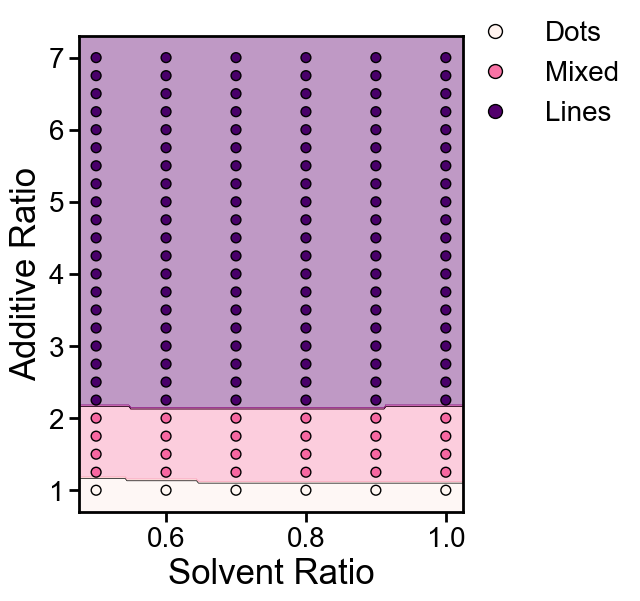

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
fig_title = f'decsion_boundary_chloro.pdf'

feature_idx1, feature_idx2 = 0, 1
fixed_feature_idx = 2
fixed_value = 0  # This is still in scaled space (0–1)

# Create meshgrid in scaled space
x1_range = np.linspace(-0.05, 1.05, 200)
x2_range = np.linspace(-0.05, 1.05, 200)
xx_scaled, yy_scaled = np.meshgrid(x1_range, x2_range)

# Prepare grid with fixed 3rd feature
grid_scaled = np.zeros((xx_scaled.size, 3))
grid_scaled[:, feature_idx1] = xx_scaled.ravel()
grid_scaled[:, feature_idx2] = yy_scaled.ravel()
grid_scaled[:, fixed_feature_idx] = fixed_value

# Predict from scaled input
y_pred = best.predict(grid_scaled).reshape(xx_scaled.shape)

# Inverse-transform grid for plotting
grid_original = xscaler.inverse_transform(grid_scaled)
xx = grid_original[:, feature_idx1].reshape(xx_scaled.shape)
yy = grid_original[:, feature_idx2].reshape(yy_scaled.shape)

# Filter original inputs based on fixed scaled value
mask = inputs[:, fixed_feature_idx] == fixed_value  # still using scaled inputs
X_filtered_scaled = inputs[mask]
y_filtered = target[mask]
X_filtered = xscaler.inverse_transform(X_filtered_scaled)

# Plot
fig, ax = plt.subplots(figsize=(5, 6))
contour = ax.contourf(xx, yy, y_pred, alpha=0.4, cmap='RdPu')
ax.contour(xx, yy, y_pred, levels=np.unique(y_pred), colors='k', linewidths=0.5)

# Scatter with inverse-transformed input
ax.scatter(
    X_filtered[:, feature_idx1], X_filtered[:, feature_idx2],
    c=y_filtered, edgecolor="black", cmap='RdPu', s=50
)
# Label axes with actual values
original_feature_names = ["Solvent Ratio", "Additive Ratio", "Feature C"]  # replace as needed
ax.set_xlabel(original_feature_names[feature_idx1])
ax.set_ylabel(original_feature_names[feature_idx2])

# Class-to-color mapping using normalized colormap
class_labels = sorted(set(target))
class_norm_vals = {0: 0.05, 1: 0.95, 2: 1.95}
class_colors = {label: cmap(norm(class_norm_vals[label])) for label in class_labels}
class_names = {0: 'Dots', 1: 'Mixed', 2: 'Lines'}

# Create a single shared legend with one handle per line
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=class_colors[cls],
        markeredgecolor='black',
        markersize=5,
        label=class_names[cls]
    )
    for cls in class_labels
]

fig.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(0.91, 0.9),
    fancybox=True,
    shadow=True,
    ncol=1,  # <- SINGLE COLUMN = one handle per line
    fontsize=20,
    frameon=False,
    markerscale=2
)

# plt.title(f"Decision boundary at {original_feature_names[fixed_feature_idx]} = {xscaler.data_min_[fixed_feature_idx]}")
fig.tight_layout()
# plt.savefig(output_path + fig_title, format='pdf', bbox_inches='tight', transparent=True)
plt.show()

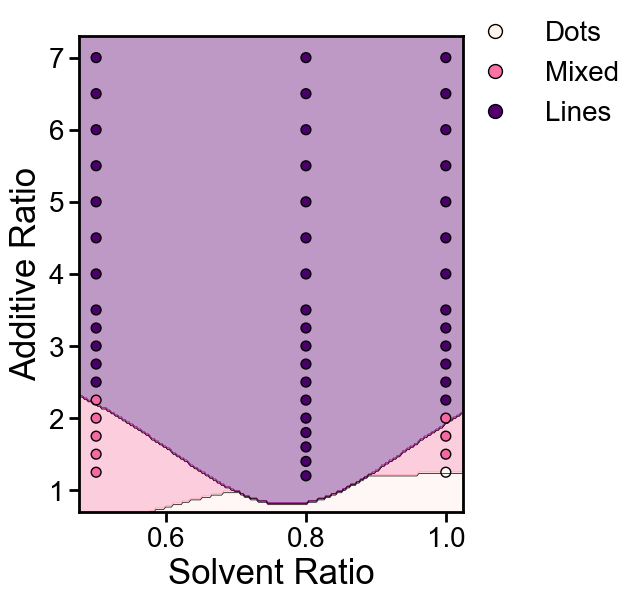

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
fig_title = f'decsion_boundary_methyl.pdf'

feature_idx1, feature_idx2 = 0, 1
fixed_feature_idx = 2
fixed_value = 1  # This is still in scaled space (0–1)

# Create meshgrid in scaled space
x1_range = np.linspace(-0.05, 1.05, 200)
x2_range = np.linspace(-0.05, 1.05, 200)
xx_scaled, yy_scaled = np.meshgrid(x1_range, x2_range)

# Prepare grid with fixed 3rd feature
grid_scaled = np.zeros((xx_scaled.size, 3))
grid_scaled[:, feature_idx1] = xx_scaled.ravel()
grid_scaled[:, feature_idx2] = yy_scaled.ravel()
grid_scaled[:, fixed_feature_idx] = fixed_value

# Predict from scaled input
y_pred = best.predict(grid_scaled).reshape(xx_scaled.shape)

# Inverse-transform grid for plotting
grid_original = xscaler.inverse_transform(grid_scaled)
xx = grid_original[:, feature_idx1].reshape(xx_scaled.shape)
yy = grid_original[:, feature_idx2].reshape(yy_scaled.shape)

# Filter original inputs based on fixed scaled value
mask = inputs[:, fixed_feature_idx] == fixed_value  # still using scaled inputs
X_filtered_scaled = inputs[mask]
y_filtered = target[mask]
X_filtered = xscaler.inverse_transform(X_filtered_scaled)

# Plot
fig, ax = plt.subplots(figsize=(5, 6))
contour = ax.contourf(xx, yy, y_pred, alpha=0.4, cmap='RdPu')
ax.contour(xx, yy, y_pred, levels=np.unique(y_pred), colors='k', linewidths=0.5)

# Scatter with inverse-transformed input
ax.scatter(
    X_filtered[:, feature_idx1], X_filtered[:, feature_idx2],
    c=y_filtered, edgecolor="black", cmap='RdPu', s=50
)
# Label axes with actual values
original_feature_names = ["Solvent Ratio", "Additive Ratio", "Feature C"]  # replace as needed
ax.set_xlabel(original_feature_names[feature_idx1])
ax.set_ylabel(original_feature_names[feature_idx2])

# Class-to-color mapping using normalized colormap
class_labels = sorted(set(target))
class_norm_vals = {0: 0.05, 1: 0.95, 2: 1.95}
class_colors = {label: cmap(norm(class_norm_vals[label])) for label in class_labels}
class_names = {0: 'Dots', 1: 'Mixed', 2: 'Lines'}

# Create a single shared legend with one handle per line
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=class_colors[cls],
        markeredgecolor='black',
        markersize=5,
        label=class_names[cls]
    )
    for cls in class_labels
]

fig.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(0.91, 0.9),
    fancybox=True,
    shadow=True,
    ncol=1,  # <- SINGLE COLUMN = one handle per line
    fontsize=20,
    frameon=False,
    markerscale=2
)

# plt.title(f"Decision boundary at {original_feature_names[fixed_feature_idx]} = {xscaler.data_min_[fixed_feature_idx]}")
fig.tight_layout()
# plt.savefig(output_path + fig_title, format='pdf', bbox_inches='tight', transparent=True)
plt.show()

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

y_pred = []
y_true = []

# Create the plasma colormap and its reverse
colors = ["#FFD700", "#000000"]
# cmap = LinearSegmentedColormap.from_list("gold_to_black", colors)
cmap = plt.cm.RdPu

# constant for classes
classes = ['Dots', 'Mixed', 'Lines']

# Build confusion matrix
cf_matrix = confusion_matrix(target.values, y_pred_full)

In [125]:
from matplotlib import rc
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=20)   
rc('xtick.major', size=7)  
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=20)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=25) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True}) 
plt.rcParams['font.family'] = 'Arial'

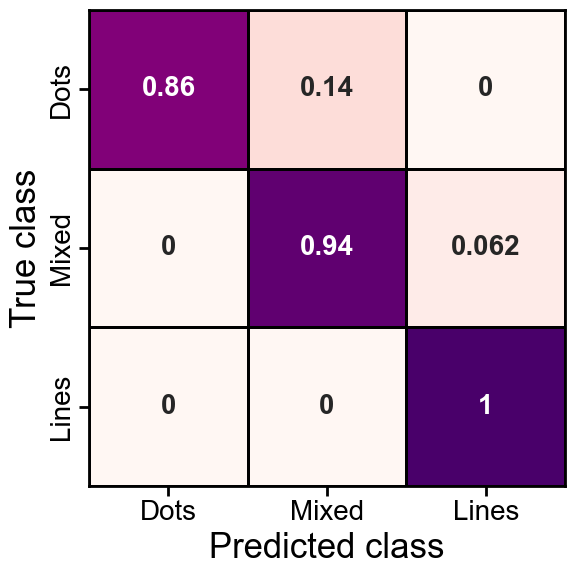

In [134]:
fig_title = f'confusion_tri.pdf'
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], 
                     index=[i for i in classes],
                     columns=[i for i in classes])

# Creating the heatmap without a color bar
plt.figure(figsize=(6,6))
ax = sn.heatmap(df_cm, cmap=cmap, annot=True, annot_kws={'weight': 'bold', 'fontsize': 20}, 
                linewidths=2, linecolor='black', cbar=False)

# Adding axis labels
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')

# Adding an outline to the heatmap
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf', transparent=True)